# How is sleep and lifestyle related to health? #
This project examines whether there is any relationship between quality of sleep, duration of sleep, physical activity etc on health. The blood pressure, BMI category, heart rate etc are used as indicators of health.

## Questions to be answered ##
- How are stress level and physical activity level related?
- How many people are in each Occupation and how many of them are male vs. female?
- Is there any relationship between BMI category and systolic blood pressure?
- Is quality of sleep affected by physical activity level or occupation?
- How does heart rate and BMI category affect systolic blood pressure?
- How is quality of sleep affected by the gender and the BMI category?
 



## References ##
The dataset used in this project is taken from here: 
https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

This project is inspired by this [notebook](http://localhost:8888/notebooks/Desktop/data-analyst-portfolio%20(1)/data-analyst-portfolio/marketing-data-analytics.ipynb?#section3_2)

In [5]:
# import necessary libraries
import pandas as pd
# reading data from the csv file
sleep_health_data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
# to get the columns of the data table
sleep_health_data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [6]:
#information about the data
sleep_health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


-There is no missing data except in the "Sleep Disorder" column. While checking the entries in the data in that column "None" is listed many times. This actually means "No Disorder". This is not actually missing data. This will be dealt with later.

In [8]:
sleep_health_data.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

(array([ 20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 [Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90'),
  Text(100.0, 0, '100')])

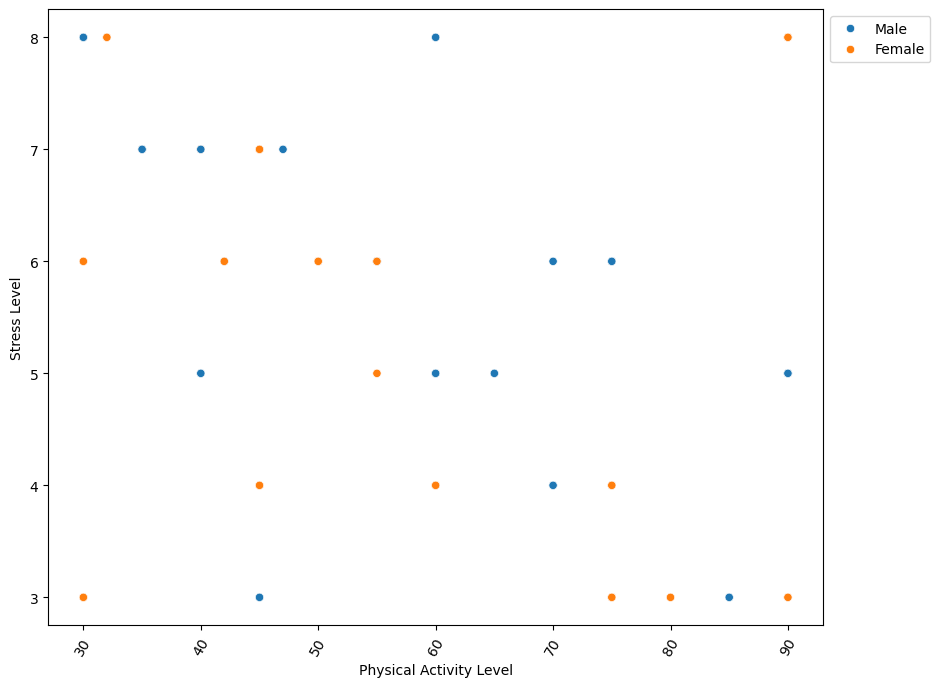

In [9]:
# import libraries for the visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 8)) 
sns.scatterplot(data = sleep_health_data, x='Physical Activity Level', y = "Stress Level", hue = 'Gender' )
# to move the legend outside the plot boundaries
plt.legend(bbox_to_anchor = (1,1))
plt.xticks(rotation = 60)


Analysis: The above scatterplot shows that as physical activity level increases stress level decreases for most people both male and female.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Nurse'),
  Text(1, 0, 'Doctor'),
  Text(2, 0, 'Engineer'),
  Text(3, 0, 'Lawyer'),
  Text(4, 0, 'Teacher'),
  Text(5, 0, 'Accountant'),
  Text(6, 0, 'Salesperson'),
  Text(7, 0, 'Software Engineer'),
  Text(8, 0, 'Scientist'),
  Text(9, 0, 'Sales Representative'),
  Text(10, 0, 'Manager')])

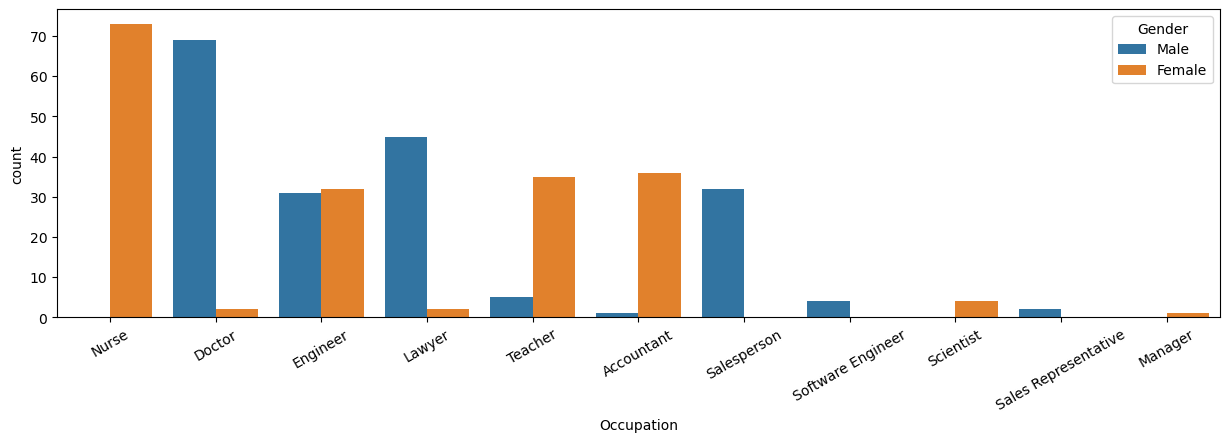

In [11]:
plt.figure(figsize = (15, 4)) 
sns.countplot(x = 'Occupation',  data = sleep_health_data, hue ='Gender', order = sleep_health_data['Occupation'].value_counts().index)

plt.xticks(rotation = 30)

Nurses are the highest in count. All of them are female. Doctors are the second highest. Most of them are male. Scientists and managers are the least in count.

In [13]:
# in order to split the blood pressure into the lower value and higher value which are systolic and diastolic respectively.
sleep_health_data['systolic'] = sleep_health_data['Blood Pressure'].apply(lambda row:int(row.split('/')[0]))
sleep_health_data['diastolic'] = sleep_health_data['Blood Pressure'].apply(lambda row:int(row.split('/')[1]))
# to view the first 5 rows
sleep_health_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,systolic,diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [14]:
# under the BMI category some enties are 'Normal' and some of them 'Normal Weight'. These are actually the same category.
sleep_health_data['BMI Category']= sleep_health_data['BMI Category'].replace('Normal Weight', 'Normal')

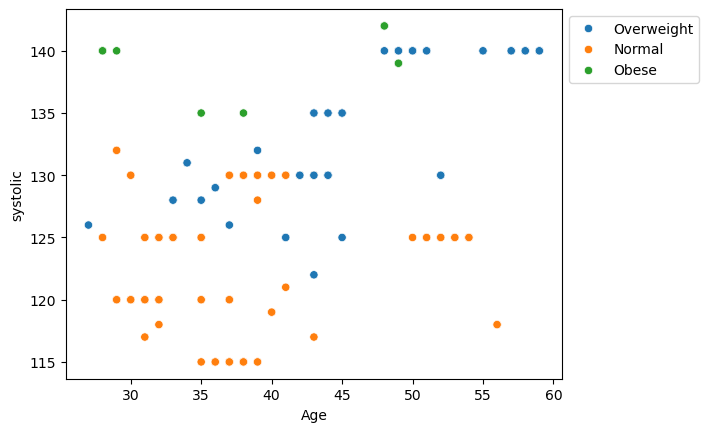

In [15]:
sns.scatterplot(x= 'Age', y= 'systolic', hue= 'BMI Category', data = sleep_health_data)
# to move the legend outside the plot boundaries
plt.legend(bbox_to_anchor = (1,1))

Analysis: It is easier to see that the systolic blood pressure of most people with normal weight is lower than people with overweight or who are obese

In [17]:
sleep_health_data['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

One of the entries for 'Sleep Disorder' column is 'None' which means 'No Disorder'. This is actually not a missing value.

In [19]:
sleep_health_data['Sleep Disorder'] = sleep_health_data['Sleep Disorder'].fillna('No Disorder')

sleep_health_data['Sleep Disorder'].value_counts()

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [20]:
sleep_health_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,systolic,diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


(array([ 20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 [Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90'),
  Text(100.0, 0, '100')])

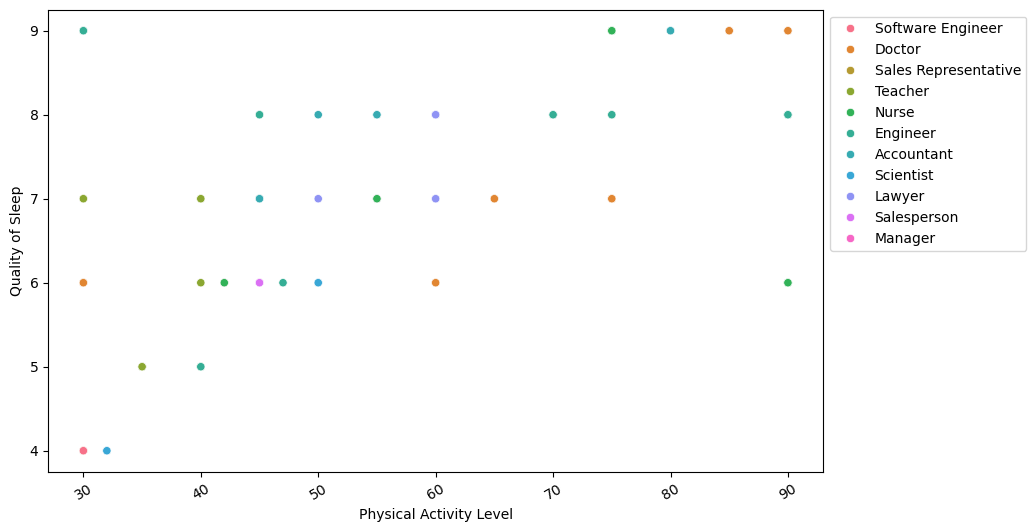

In [21]:
plt.figure(figsize = (10, 6)) 
sns.scatterplot(x = 'Physical Activity Level', y= 'Quality of Sleep', hue= 'Occupation', data = sleep_health_data)
# to move the legend outside the plot boundaries
plt.legend(bbox_to_anchor = (1,1))
plt.xticks(rotation = 30)

Analysis: For most people as physical activity level increases quality of sleep increases

<Axes: >

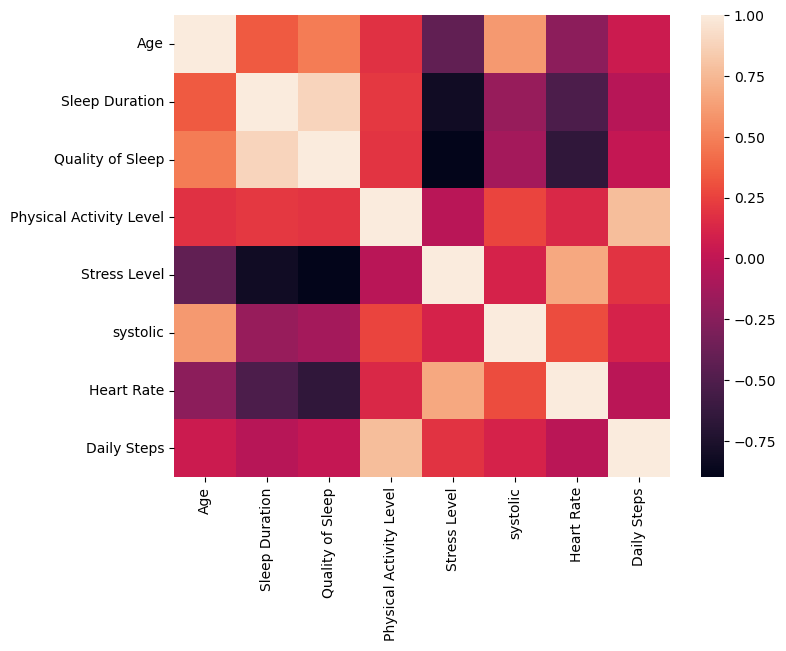

In [23]:
# make a new dataframe with only the numerical variables
data1 = sleep_health_data[[ 'Age', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
        'systolic', 'Heart Rate', 'Daily Steps']]
plt.figure(figsize = (8,6))
#find the correlation between the variables
data1.corr()
sns.heatmap(data1.corr())

In [ ]:
Analysis: The lighter colors show positive correlation and the darker colors show negative correlation. The middle color shows
no relationship or zero correlation.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, '3000'),
  Text(1, 0, '3300'),
  Text(2, 0, '3500'),
  Text(3, 0, '3700'),
  Text(4, 0, '4000'),
  Text(5, 0, '4100'),
  Text(6, 0, '4200'),
  Text(7, 0, '4800'),
  Text(8, 0, '5000'),
  Text(9, 0, '5200'),
  Text(10, 0, '5500'),
  Text(11, 0, '5600'),
  Text(12, 0, '6000'),
  Text(13, 0, '6200'),
  Text(14, 0, '6800'),
  Text(15, 0, '7000'),
  Text(16, 0, '7300'),
  Text(17, 0, '7500'),
  Text(18, 0, '8000'),
  Text(19, 0, '10000')])

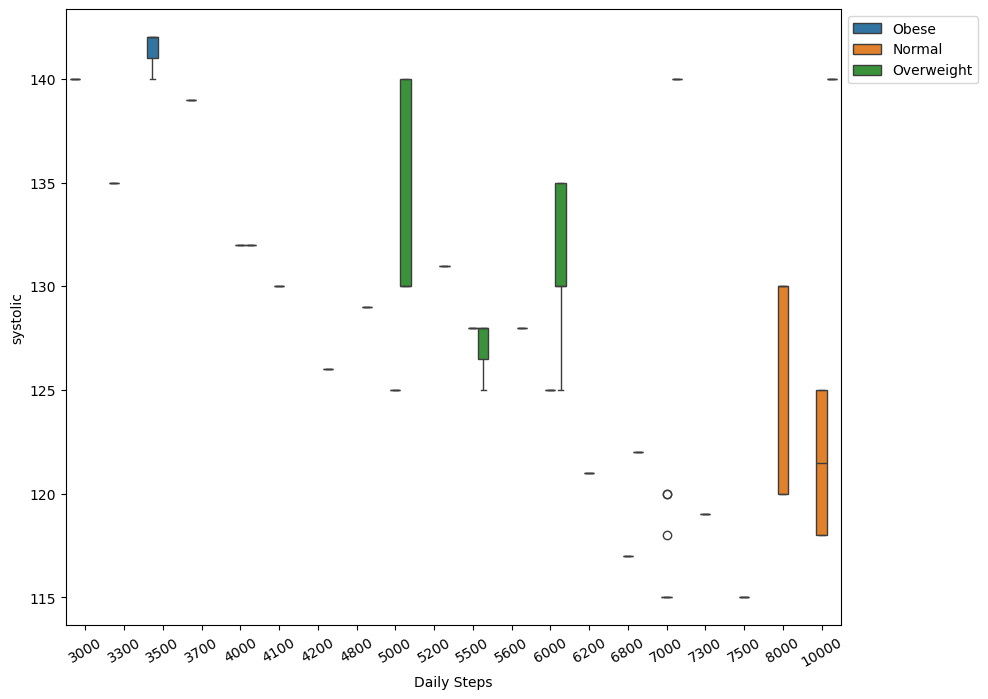

In [24]:
plt.figure(figsize = (10, 8))
sns.boxplot(x = 'Daily Steps', y= 'systolic', hue='BMI Category', data = sleep_health_data)
# to move the legend outside the plot boundaries
plt.legend(bbox_to_anchor=(1,1))
plt.xticks(rotation = 30)

Analysis: As the daily steps increase, the systolic pressure decreases. For obese people daily steps are less compared to people with normal weight where daily steps
are really high.

(array([60., 65., 70., 75., 80., 85., 90.]),
 [Text(60.0, 0, '60'),
  Text(65.0, 0, '65'),
  Text(70.0, 0, '70'),
  Text(75.0, 0, '75'),
  Text(80.0, 0, '80'),
  Text(85.0, 0, '85'),
  Text(90.0, 0, '90')])

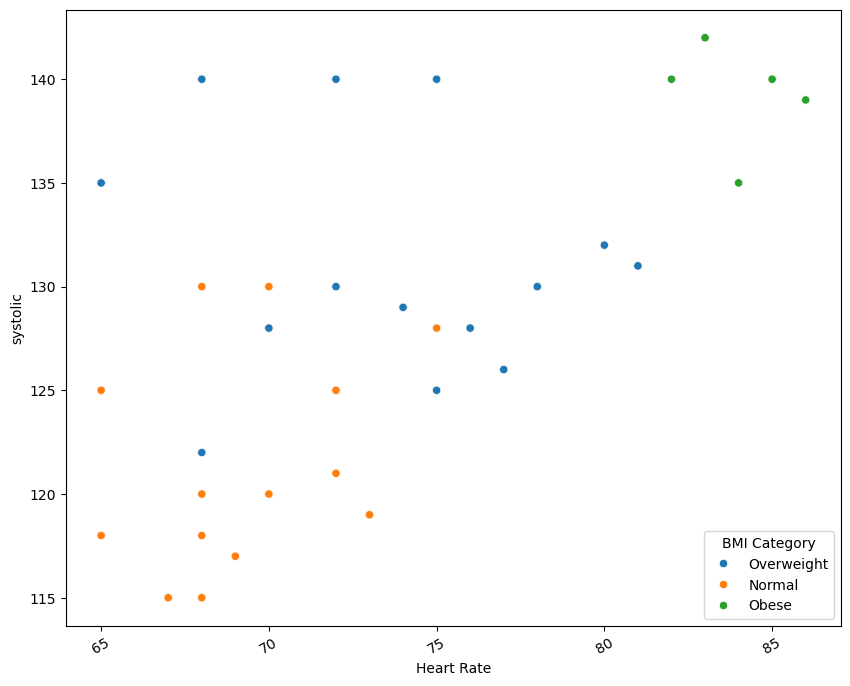

In [26]:
plt.figure(figsize = (10, 8))
sns.scatterplot(x = 'Heart Rate', y= 'systolic', hue='BMI Category', data = sleep_health_data)
plt.xticks(rotation = 30)

Analysis: Obese people are in the upper right corner indicating high heart rate and 
high systolic pressure. The normal people are in the bottom left area and the overweight people are in the middle.

In [28]:
sleep_health_data['Sleep Disorder'] = sleep_health_data['Sleep Disorder'].fillna('No Disorder')
sleep_health_data['Sleep Disorder'] = sleep_health_data['Sleep Disorder'].replace('SA', 'Sleep Apnea')
sleep_health_data['Sleep Disorder'].unique()
sleep_health_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,systolic,diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


([0, 1, 2],
 [Text(0, 0, 'Normal'), Text(1, 0, 'Overweight'), Text(2, 0, 'Obese')])

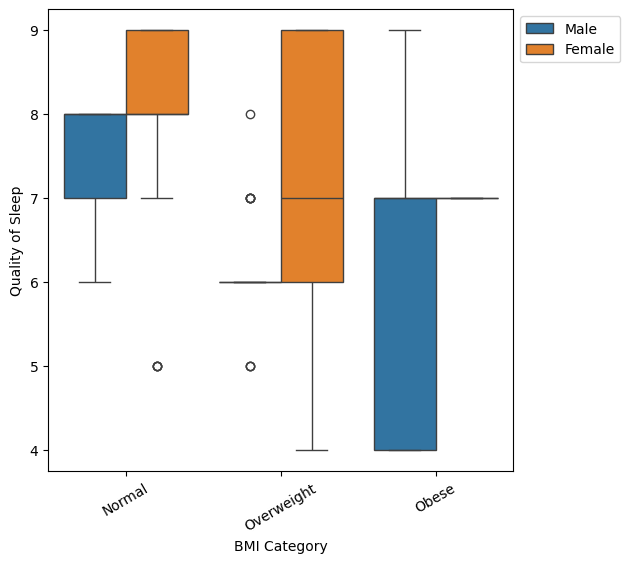

In [29]:
plt.figure(figsize = (6, 6)) 
sns.boxplot(x = 'BMI Category', y= 'Quality of Sleep', hue= 'Gender', order=['Normal', 'Overweight', 'Obese'],data = sleep_health_data)
# to move the legend outside the plot boundaries
plt.legend(bbox_to_anchor = (1,1))
plt.xticks(rotation = 30)


Analysis: The quality of sleep decreases as the weight goes up. The quality of sleep is better in females compared to male.

In order to get a better picture of all factors affecting quality of sleep at once the scatterplots are combined in one diagram as below.

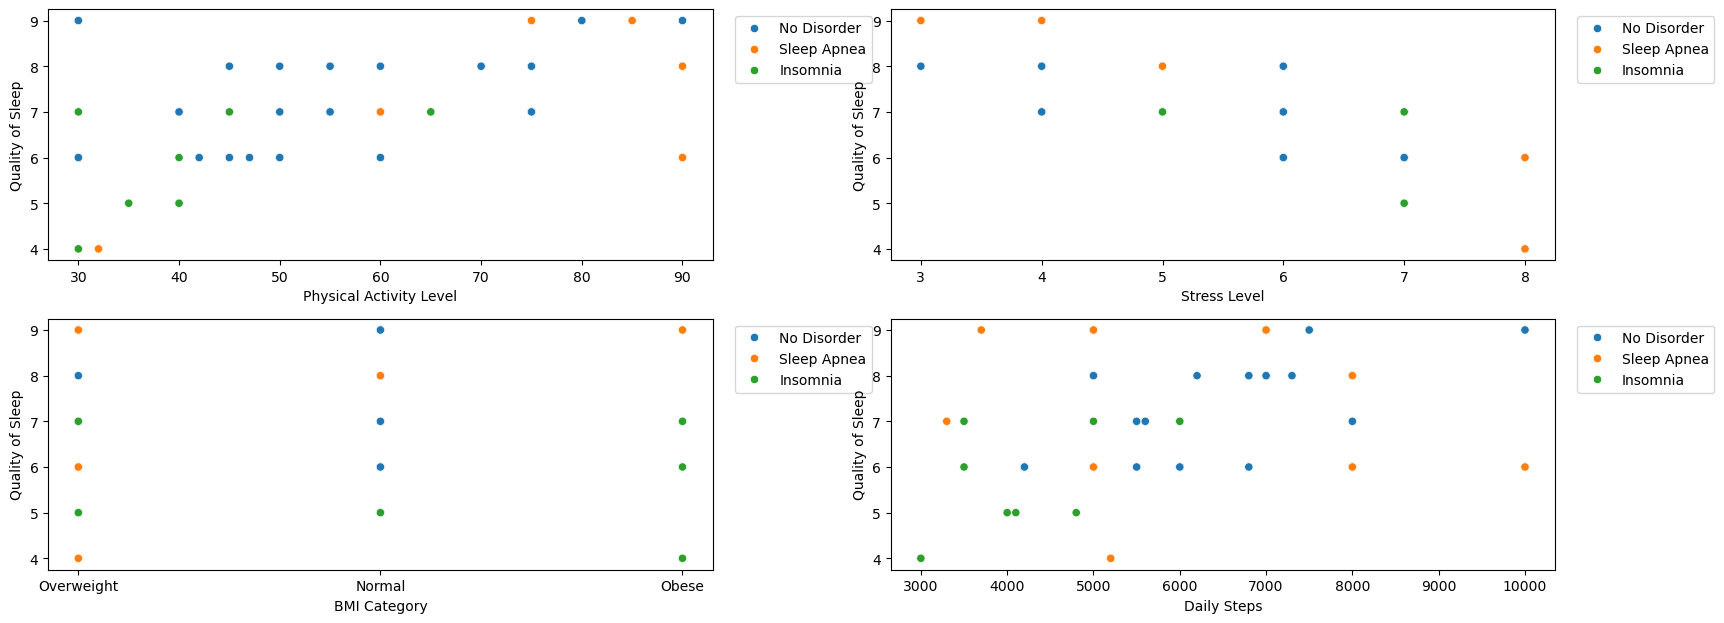

In [32]:
factors = ['Physical Activity Level', 'Stress Level', 'BMI Category', 'Daily Steps']
plot = 0

fig = plt.figure(figsize = (17,9))
for i in range(len(factors)):
    plot += 1
   
    ax = plt.subplot(3, 2, plot)

    sns.scatterplot(x= factors[i], y= 'Quality of Sleep',  hue= 'Sleep Disorder', data=sleep_health_data)
    
    plt.legend(bbox_to_anchor=(1.25,1))
    
    plt.subplots_adjust(top = 3, hspace = .75, wspace = .5)
         
plt.tight_layout()       
plt.show()
    

In order to get a better picture of all factors affecting heart rate at once the boxplots are combined in one diagram as below.

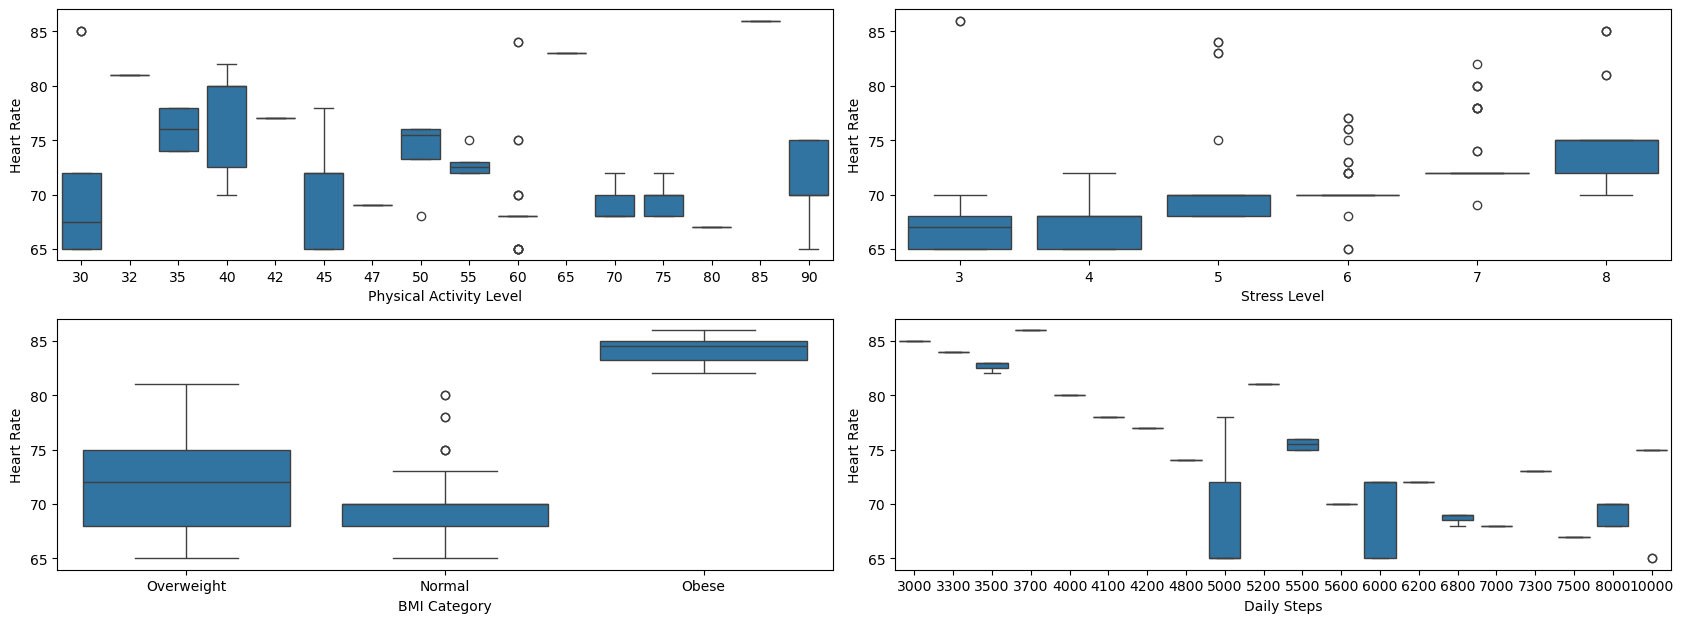

In [34]:
factors = ['Physical Activity Level', 'Stress Level', 'BMI Category', 'Daily Steps']
plot = 0

fig = plt.figure(figsize = (17,9))
#for i in range(len(factors)):
for factor in factors:
    plot += 1
   
    ax = plt.subplot(3, 2, plot)

    sns.boxplot(x= factor, y= 'Heart Rate',  data=sleep_health_data)
    
    #plt.legend(bbox_to_anchor=(1.25,1))
    
    plt.subplots_adjust(top = 3, hspace = .75, wspace = .5)
         
plt.tight_layout()       
plt.show()
    

In order to get a better picture of all factors affecting systolic pressure at once the boxplots are combined in one diagram as below.

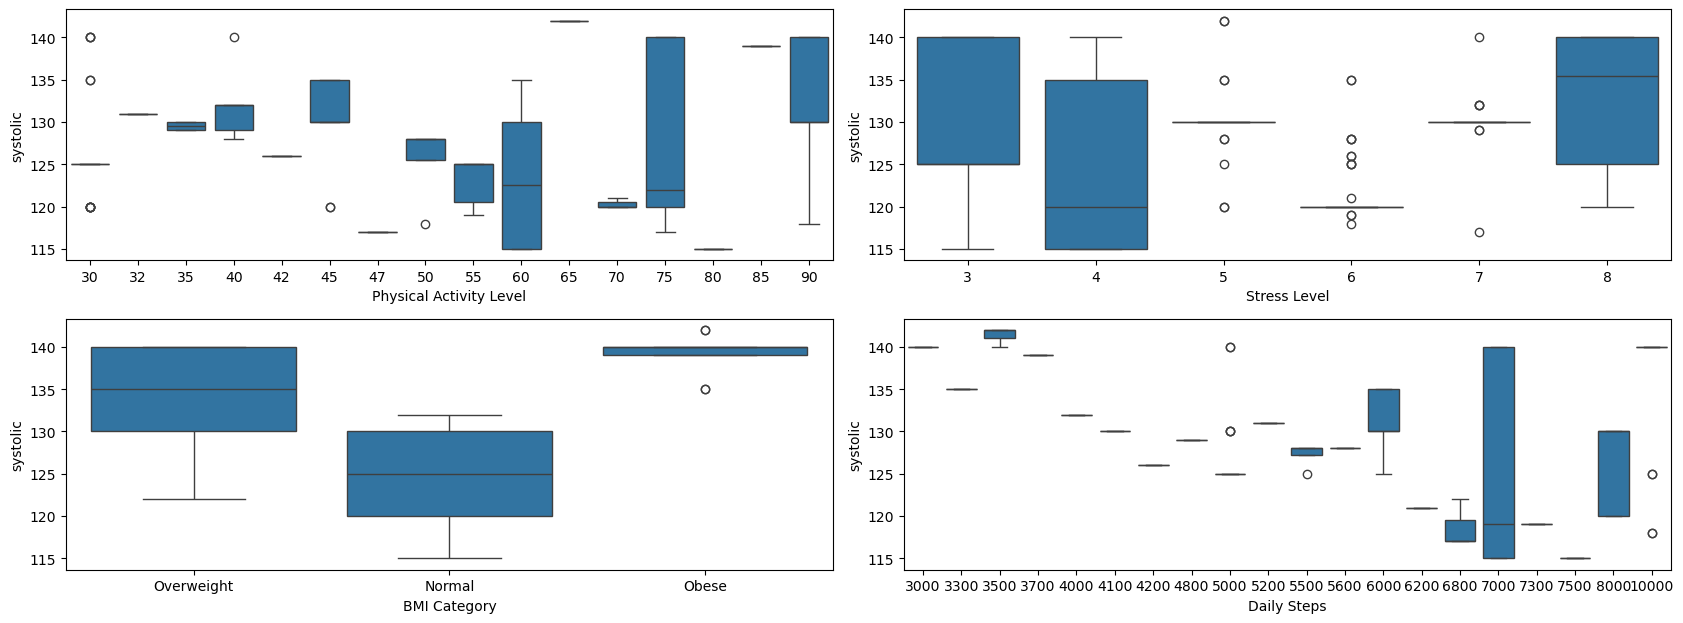

In [36]:
factors = ['Physical Activity Level', 'Stress Level', 'BMI Category', 'Daily Steps']
plot = 0

fig = plt.figure(figsize = (17,9))
for i in range(len(factors)):
    plot += 1
   
    ax = plt.subplot(3, 2, plot)

    sns.boxplot(x= factors[i], y= 'systolic',  data=sleep_health_data)
    
    #plt.legend(bbox_to_anchor=(1.25,1))
    
    plt.subplots_adjust(top = 3, hspace = .75, wspace = .5)
         
plt.tight_layout()       
plt.show()
    